# YOLO11n Grouped Clean-Light Baseline Noise Ablation

Kaggle notebook. It retrains the accepted leakage-safe baseline, then evaluates the trained checkpoint on the same synthetic noise conditions used in the teammate SimAM+CA noise notebook.

Baseline contract:

- YOLO11n-seg
- stratified grouped-specimen split
- seed 42
- clean-light YOLO augmentation
- default Ultralytics Albumentations hook enabled
- clean training data; noise is applied only to test images

## Important Outputs To Download

- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_summary.csv`
- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_paper_row.csv`
- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_all.csv`
- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_summary.csv`
- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/split_manifests/`
- `/kaggle/working/shrimp_yolo11n_grouped_clean_baseline/baseline_noise_ablation_results.zip`
- selected `best.pt` from the run folder listed in the CSVs

## Run Controls

In [1]:
# Run controls
# Paper-facing baseline: one model, one fair split, one seed.
# This is intentionally extracted from the grouped model-sweep notebook so the
# baseline uses the same train/eval contract as the model-selection experiment.
EXECUTION_PLAN = 'yolo11n_grouped_clean_baseline'
SMOKE_RUN = False
SEEDS = [42]

# Paper baseline keeps the default Ultralytics Albumentations hook enabled.
# Set True only for a diagnostic no-hidden-hook control, not for paper metrics.
DISABLE_ULTRALYTICS_ALBUMENTATIONS = False

YOLO_MODELS = [
    'yolo11n-seg.pt',
]

SPLIT_POLICIES = [
    {
        'key': 'stratified_grouped_specimen',
        'name': 'Stratified grouped-specimen split',
        'description': 'Disease-stratified split where all images from one shrimp stay together.',
    },
]

INCLUDE_M_MODELS = False

print('EXECUTION_PLAN:', EXECUTION_PLAN)
print('SMOKE_RUN:', SMOKE_RUN)
print('SEEDS:', SEEDS)
print('DISABLE_ULTRALYTICS_ALBUMENTATIONS:', DISABLE_ULTRALYTICS_ALBUMENTATIONS)
print('YOLO_MODELS:', YOLO_MODELS)
print('SPLIT_POLICIES:', [p['key'] for p in SPLIT_POLICIES])


EXECUTION_PLAN: yolo11n_grouped_clean_baseline
SMOKE_RUN: False
SEEDS: [42]
DISABLE_ULTRALYTICS_ALBUMENTATIONS: False
YOLO_MODELS: ['yolo11n-seg.pt']
SPLIT_POLICIES: ['stratified_grouped_specimen']


## Dataset Download

In [2]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec('roboflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

from roboflow import Roboflow

ROBOFLOW_API_KEY_DIRECT = 'KOEk0qLzBFDc7zfyxtgs'
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdishandsegv2'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'


def get_roboflow_api_key():
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()


api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError(
        'Missing Roboflow API key. Add a Kaggle Secret named ROBOFLOW_API_KEY, '
        'set the ROBOFLOW_API_KEY environment variable, or temporarily fill ROBOFLOW_API_KEY_DIRECT.'
    )

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to shrimpDisHandSegV2-1 in yolo26:: 100%|██████████| 2301/2301 [00:00<00:00, 3187.15it/s]


## Leakage-Safe Split Helpers

In [3]:
import os
import random
import re
import shutil
from collections import defaultdict, Counter
from pathlib import Path

SEED = 42
random.seed(SEED)

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
train_path = os.path.join(base_path, 'train')
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Prevent leakage from multiple photos of the same shrimp.
# Expected original filename: <diseasename>-<shrimpid>-img-<imgnum>.jpg
# Roboflow may export names like <diseasename>-<shrimpid>-img-<imgnum>_jpg.rf.<hash>.jpg.
# Example disease names: Healthy, BG, WSSV_BG, WSSV.
GROUP_SPLIT_BY_SHRIMP = True
GROUP_STRATIFY_BY_DISEASE = True
REBUILD_SPLIT_FROM_ALL_SPLITS = True
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)


def normalize_roboflow_stem(stem):
    """Recover the original filename stem from Roboflow-exported names."""
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return stem


for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)


def parse_shrimp_group_key(image_name):
    """Return a stable group key so all images from one shrimp stay in one split."""
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return f'unparsed::{Path(image_name).stem}', 'unparsed', None, None

    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    img_num = int(match.group('img_num'))
    group_key = f'{disease.lower()}::{shrimp_id}'
    return group_key, disease, shrimp_id, img_num


def image_files_in_split(split):
    image_dir = Path(base_path) / split / 'images'
    return sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def move_image_and_label(image_path, target_split):
    target_img_dir = Path(base_path) / target_split / 'images'
    target_lbl_dir = Path(base_path) / target_split / 'labels'
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_name = f'{image_path.stem}.txt'
    label_src = image_path.parent.parent / 'labels' / label_name
    image_dst = target_img_dir / image_path.name
    label_dst = target_lbl_dir / label_name

    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination would be overwritten: {image_dst}')
        shutil.move(str(image_path), str(image_dst))

    if label_src.exists():
        if label_src.resolve() != label_dst.resolve():
            if label_dst.exists():
                raise FileExistsError(f'Duplicate label destination would be overwritten: {label_dst}')
            shutil.move(str(label_src), str(label_dst))
    else:
        label_dst.write_text('')


def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))

    for image_path in sorted(all_images):
        move_image_and_label(image_path, 'train')

    return image_files_in_split('train')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def disease_for_group(filenames):
    diseases = []
    for filename in filenames:
        _, disease, _, _ = parse_shrimp_group_key(filename)
        diseases.append(disease)
    counts = Counter(diseases)
    if len(counts) > 1:
        print(f'Warning: group has mixed disease names: {dict(counts)}')
    return counts.most_common(1)[0][0]


def split_one_stratum(items):
    n = len(items)
    train_count = int(TRAIN_RATIO * n)
    val_count = int(VAL_RATIO * n)
    test_count = n - train_count - val_count

    if n >= 3:
        if val_count == 0:
            val_count = 1
            train_count -= 1
        if test_count == 0:
            test_count = 1
            train_count -= 1
    if train_count < 1 and n > 0:
        train_count = 1
    while train_count + val_count + test_count > n:
        train_count -= 1
    test_count = n - train_count - val_count

    return (
        items[:train_count],
        items[train_count:train_count + val_count],
        items[train_count + val_count:],
    )


def grouped_stratified_split(group_items):
    strata = defaultdict(list)
    for group_key, filenames in group_items:
        strata[disease_for_group(filenames)].append((group_key, filenames))

    split_to_groups = {'train': [], 'valid': [], 'test': []}
    rng = random.Random(SEED)
    for disease, items in sorted(strata.items()):
        items = sorted(items, key=lambda item: item[0])
        rng.shuffle(items)
        train_items, val_items, test_items = split_one_stratum(items)
        split_to_groups['train'].extend(train_items)
        split_to_groups['valid'].extend(val_items)
        split_to_groups['test'].extend(test_items)
        print(
            f'  - {disease}: {len(train_items)} train groups, '
            f'{len(val_items)} valid groups, {len(test_items)} test groups'
        )

    for split in split_to_groups:
        split_to_groups[split] = sorted(split_to_groups[split], key=lambda item: item[0])
    return split_to_groups


def grouped_random_split(group_items):
    group_items = sorted(group_items, key=lambda item: item[0])
    random.Random(SEED).shuffle(group_items)
    n_groups = len(group_items)
    train_group_count = int(TRAIN_RATIO * n_groups)
    val_group_count = int(VAL_RATIO * n_groups)
    return {
        'train': group_items[:train_group_count],
        'valid': group_items[train_group_count:train_group_count + val_group_count],
        'test': group_items[train_group_count + val_group_count:],
    }


def split_summary(split_groups):
    group_diseases = Counter()
    image_diseases = Counter()
    for _, filenames in split_groups:
        group_diseases[disease_for_group(filenames)] += 1
        for filename in filenames:
            _, disease, _, _ = parse_shrimp_group_key(filename)
            image_diseases[disease] += 1
    return group_diseases, image_diseases


def split_grouped_by_shrimp():
    if REBUILD_SPLIT_FROM_ALL_SPLITS:
        image_paths = rebuild_train_pool_from_all_splits()
    else:
        image_paths = image_files_in_split('train')

    groups = defaultdict(list)
    disease_counts = Counter()
    unparsed = []

    for image_path in image_paths:
        group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
        groups[group_key].append(image_path.name)
        disease_counts[disease] += 1
        if disease == 'unparsed':
            unparsed.append(image_path.name)

    group_items = sorted(groups.items(), key=lambda item: item[0])
    if GROUP_STRATIFY_BY_DISEASE:
        print('Building shrimp-grouped, disease-stratified split:')
        split_to_groups = grouped_stratified_split(group_items)
    else:
        print('Building shrimp-grouped random split:')
        split_to_groups = grouped_random_split(group_items)

    for split, split_groups in split_to_groups.items():
        for _, filenames in split_groups:
            for filename in filenames:
                move_image_and_label(Path(base_path) / 'train' / 'images' / filename, split)

    print('Shrimp-grouped split complete:')
    for split, split_groups in split_to_groups.items():
        image_count = sum(len(filenames) for _, filenames in split_groups)
        group_diseases, image_diseases = split_summary(split_groups)
        print(f'  - {split}: {len(split_groups)} shrimp groups, {image_count} images')
        print(f'    group disease counts: {dict(sorted(group_diseases.items()))}')
        print(f'    image disease counts: {dict(sorted(image_diseases.items()))}')

    print('Source filename disease counts before split:', dict(sorted(disease_counts.items())))
    if unparsed:
        print(f'Warning: {len(unparsed)} filenames did not match the shrimp naming pattern. They were split as single-image groups.')
        print('First unparsed examples:', unparsed[:10])

    group_to_split = {}
    leakage = []
    for split in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split):
            group_key, *_ = parse_shrimp_group_key(image_path.name)
            previous_split = group_to_split.setdefault(group_key, split)
            if previous_split != split:
                leakage.append((group_key, previous_split, split, image_path.name))

    if leakage:
        raise RuntimeError(f'Shrimp-level split leakage detected: {leakage[:10]}')
    print('Shrimp-level leakage check passed.')
    remove_yolo_label_caches(base_path)


if GROUP_SPLIT_BY_SHRIMP:
    split_grouped_by_shrimp()
else:
    valid_images_dir = Path(base_path) / 'valid' / 'images'
    test_images_dir = Path(base_path) / 'test' / 'images'

    if not any(valid_images_dir.glob('*')) and not any(test_images_dir.glob('*')):
        image_files = sorted(
            f for f in os.listdir(os.path.join(train_path, 'images'))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )
        random.shuffle(image_files)

        train_count = int(0.8 * len(image_files))
        val_count = int(0.1 * len(image_files))
        val_files = image_files[train_count:train_count + val_count]
        test_files = image_files[train_count + val_count:]

        def move_files(files, target_split):
            for f in files:
                move_image_and_label(Path(train_path) / 'images' / f, target_split)

        move_files(val_files, 'valid')
        move_files(test_files, 'test')
        print(f"Image-level split complete: {len(image_files) - len(val_files) - len(test_files)} train, {len(val_files)} val, {len(test_files)} test")
        remove_yolo_label_caches(base_path)
    else:
        print('Existing valid/test split detected. Keeping downloaded split.')


Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    group disease counts: {'BG': 8, 'Healthy': 15, 'WSSV': 13, 'WSSV_BG': 9}
    image disease counts: {'BG': 24, 'Healthy': 41, 'WSSV': 38, 'WSSV_BG': 26}
Source filename disease counts before split: {'BG': 198, 'Healthy': 403, 'WSSV': 328, 

In [4]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('ultralytics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])

from ultralytics import YOLO
import os
from pathlib import Path

base_path = '/kaggle/working/shrimpDisHandSegV2-1'
data_yaml_path = os.path.join(base_path, 'data.yaml')

# Baseline model is defined in the run-control cell. Keep this smoke check
# synchronized with the paper-facing one-row baseline configuration.
YOLO_MODEL = YOLO_MODELS[0]
MODEL_STEM = Path(YOLO_MODEL).stem
RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_stratified_grouped_specimen'

# Load once here as a smoke check. Training cells instantiate fresh models per experiment.
model = YOLO(YOLO_MODEL)
print('Configured baseline segmentation model:')
for configured_model in YOLO_MODELS:
    print(f'  - {configured_model}')
print(f'Run name prefix: {RUN_BASE_NAME}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Configured baseline segmentation model:
  - yolo11n-seg.pt
Run name prefix: yolo11n-seg_shrimp_seg_stratified_grouped_specimen


In [5]:
import yaml

# Update data.yaml to use correct paths
with open(data_yaml_path, 'r') as f:
    content = yaml.safe_load(f)

content['train'] = '/kaggle/working/shrimpDisHandSegV2-1/train/images'
content['val'] = '/kaggle/working/shrimpDisHandSegV2-1/valid/images'
content['test'] = '/kaggle/working/shrimpDisHandSegV2-1/test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(content, f)

print("data.yaml updated with absolute paths.")

data.yaml updated with absolute paths.


### Exploratory Data Analysis (EDA)
We will analyze the dataset to understand the class distribution and visualize some sample images with their masks.

In [6]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 584
  - healthy negative images: 321
  - WSSV: 446 mask instances
  - BG: 364 mask instances

Valid Split:
  - labeled disease images: 74
  - healthy negative images: 41
  - WSSV: 56 mask instances
  - BG: 46 mask instances

Test Split:
  - labeled disease images: 88
  - healthy negative images: 41
  - WSSV: 67 mask instances
  - BG: 52 mask instances


### Visualizing Class Imbalance
An imbalanced dataset can cause the model to be biased. Let's visualize the distribution across our splits.

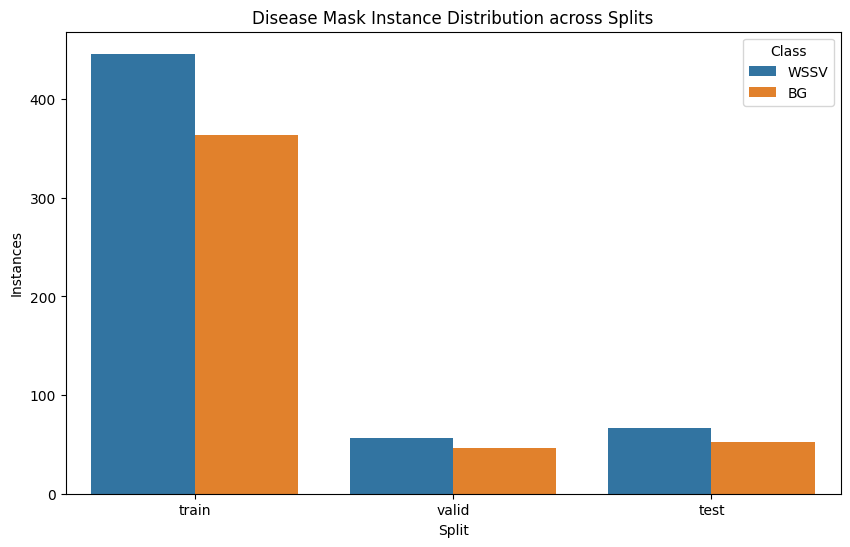

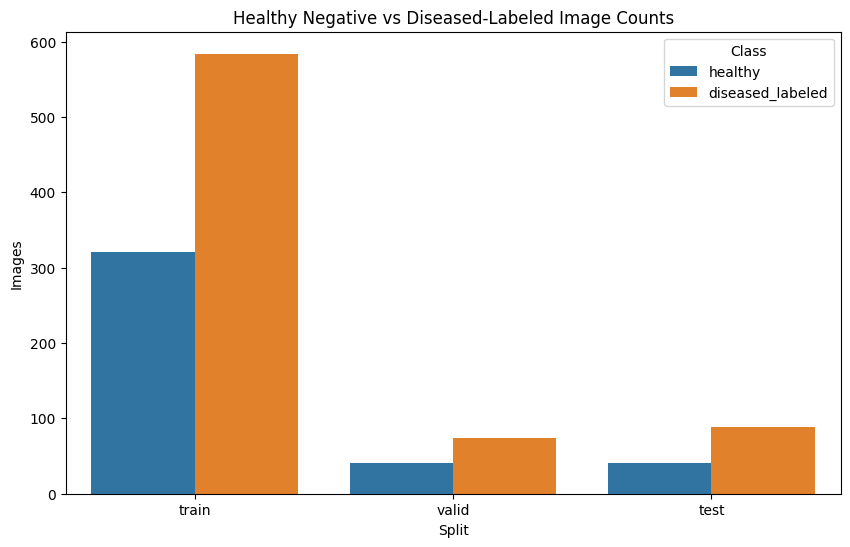

Train: 44.94% blackgill instances; 35.47% healthy negative images
Valid: 45.10% blackgill instances; 35.65% healthy negative images
Test: 43.70% blackgill instances; 31.78% healthy negative images


In [7]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

#### Observations:
1. **High Disease-Class Imbalance**: `blackgill` is a small fraction of disease mask instances.
2. **Healthy Negatives Are Real Data**: Empty label files are healthy shrimp images, not missing annotations.
3. **Evaluation Must Split Responsibilities**:
   - Diseased/labeled images should be evaluated with box/mask mAP and recall.
   - Healthy/empty-label images should be evaluated with false-positive rate and false-positive masks per image.

**Recommendation**: Keep healthy images in training as negative controls, but report healthy false-positive metrics separately instead of mixing them into disease mask mAP interpretation.

### Optional Minority RandAugment Oversampling
The baseline starts with `ENABLE_MINORITY_OVERSAMPLING = False`. Turn it on later to create RandAugment-based minority samples. The implementation uses label-preserving photometric RandAugment operations so segmentation polygons remain valid.


In [8]:
import cv2
import os
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

ENABLE_MINORITY_OVERSAMPLING = False
MINORITY_CLASS_ID = 0
MINORITY_OVERSAMPLING_MULTIPLIER = 8
RAND_AUGMENT_NUM_OPS = 2
RAND_AUGMENT_MAGNITUDE = 9
RAND_AUGMENT_MAX_MAGNITUDE = 30

# Geometric RandAugment ops are intentionally excluded here because this is
# segmentation data. Photometric ops preserve the existing polygon labels.
RAND_AUGMENT_OPS = [
    'autocontrast',
    'equalize',
    'solarize',
    'posterize',
    'color',
    'contrast',
    'brightness',
    'sharpness',
]


def find_image_for_label(image_dir, label_file):
    stem = Path(label_file).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None


def remove_yolo_label_caches(base_path):
    for cache_path in Path(base_path).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
        else:
            healthy += 1
    return labeled, healthy


def randaugment_level(max_value, signed=False):
    magnitude = RAND_AUGMENT_MAGNITUDE / RAND_AUGMENT_MAX_MAGNITUDE
    value = magnitude * max_value
    if signed and random.random() < 0.5:
        value *= -1
    return value


def apply_randaugment_op(image, op_name):
    if op_name == 'autocontrast':
        return ImageOps.autocontrast(image)
    if op_name == 'equalize':
        return ImageOps.equalize(image)
    if op_name == 'solarize':
        threshold = int(256 - randaugment_level(256))
        return ImageOps.solarize(image, threshold=max(0, min(256, threshold)))
    if op_name == 'posterize':
        bits = int(round(8 - randaugment_level(4)))
        return ImageOps.posterize(image, bits=max(4, min(8, bits)))
    if op_name == 'color':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Color(image).enhance(max(0.1, factor))
    if op_name == 'contrast':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Contrast(image).enhance(max(0.1, factor))
    if op_name == 'brightness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Brightness(image).enhance(max(0.1, factor))
    if op_name == 'sharpness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Sharpness(image).enhance(max(0.1, factor))
    raise ValueError(f'Unsupported RandAugment op: {op_name}')


def apply_label_preserving_randaugment(image):
    image = image.convert('RGB')
    ops = random.choices(RAND_AUGMENT_OPS, k=RAND_AUGMENT_NUM_OPS)
    for op_name in ops:
        image = apply_randaugment_op(image, op_name)
    return image


def augment_minority_class(base_path, class_id_to_target=0, multiplier=5):
    train_img_dir = os.path.join(base_path, 'train', 'images')
    train_lbl_dir = os.path.join(base_path, 'train', 'labels')

    label_files = [f for f in os.listdir(train_lbl_dir) if f.endswith('.txt')]
    augmented_count = 0
    skipped_count = 0
    random.seed(SEED)

    for label_file in label_files:
        if label_file.startswith('randaug_'):
            continue

        label_path = os.path.join(train_lbl_dir, label_file)
        with open(label_path, 'r') as f:
            content = [line.strip() for line in f.readlines() if line.strip()]

        has_target = any(int(line.split()[0]) == class_id_to_target for line in content)
        if not has_target:
            continue

        img_path = find_image_for_label(train_img_dir, label_file)
        if img_path is None:
            skipped_count += 1
            continue

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            skipped_count += 1
            continue

        for m in range(multiplier):
            aug_img = apply_label_preserving_randaugment(image)
            aug_image_name = f'randaug_{m}_{img_path.stem}.jpg'
            aug_label_name = f'randaug_{m}_{Path(label_file).stem}.txt'
            aug_img.save(os.path.join(train_img_dir, aug_image_name), quality=95)
            with open(os.path.join(train_lbl_dir, aug_label_name), 'w') as f:
                f.write('\n'.join(content) + '\n')
            augmented_count += 1

    remove_yolo_label_caches(base_path)
    labeled, healthy = count_labeled_images(train_lbl_dir)
    target_name = class_names[class_id_to_target] if class_id_to_target < len(class_names) else str(class_id_to_target)
    print(f'Created {augmented_count} RandAugment samples for class {target_name}.')
    print(f'Skipped {skipped_count} source labels due to missing image or invalid labels.')
    print(f'Train labels after augmentation: {labeled} diseased/labeled images, {healthy} healthy negative label files.')


if ENABLE_MINORITY_OVERSAMPLING:
    augment_minority_class(base_path, class_id_to_target=MINORITY_CLASS_ID, multiplier=MINORITY_OVERSAMPLING_MULTIPLIER)
else:
    print('Minority RandAugment oversampling disabled for the clean baseline.')


Minority RandAugment oversampling disabled for the clean baseline.


## Training Helpers

The following helpers are inherited from the grouped model-sweep notebook. They define the clean-light YOLO augmentation policy, control the default Ultralytics Albumentations hook, build labeled-only and healthy-only evaluation datasets, and compute healthy-aware metrics.


## Training and Evaluation Helpers

In [9]:
import csv
import gc
import math
import shutil
import time
from pathlib import Path

import cv2
import pandas as pd
import yaml
from IPython.display import display

EXPERIMENT_ROOT = Path('/kaggle/working/shrimp_yolo11n_grouped_clean_baseline')
RUNS_DIR = Path('/kaggle/working/runs/segment')
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_RUN = bool(globals().get('SMOKE_RUN', False))
TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 30
RUN_TEST_EVALUATION = not SMOKE_RUN

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

EXPERIMENTS = [
    {
        'key': 'clean_light_aug_baseline',
        'name': 'Clean Baseline - Grouped Stratified Light YOLO Augmentation',
        'apply_clahe': False,
    },
]

CLEAN_LIGHT_AUG_TRAIN_ARGS = {
    # Main clean baseline: explicit light YOLO augmentation for regularization.
    # Mosaic, mixup, copy-paste, and erasing stay disabled. The hidden Ultralytics
    # Albumentations hook is controlled by DISABLE_ULTRALYTICS_ALBUMENTATIONS.
    'auto_augment': None,
    'erasing': 0.0,
    'mosaic': 0.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'fliplr': 0.5,
    'flipud': 0.0,
    'hsv_h': 0.01,
    'hsv_s': 0.35,
    'hsv_v': 0.20,
    'degrees': 0.0,
    'translate': 0.05,
    'scale': 0.20,
    'shear': 0.0,
    'perspective': 0.0,
    'multi_scale': 0.0,
    'bgr': 0.0,
}


def configure_ultralytics_albumentations_hook(disable=False):
    """Disable or restore Ultralytics' default Albumentations hook for this run."""
    try:
        import importlib
        import ultralytics.data.augment as yolo_augment
    except Exception as exc:
        print(f'Could not access Ultralytics Albumentations hook: {exc}')
        return

    if not disable:
        # Important in notebooks: a previous cell/run may already have monkey-patched
        # Albumentations. Reloading restores the original Ultralytics class.
        importlib.reload(yolo_augment)
        print('Ultralytics Albumentations hook enabled/restored for this run.')
        return

    class NoOpAlbumentations:
        contains_spatial = False

        def __init__(self, *args, **kwargs):
            self.transform = None

        def __call__(self, labels):
            return labels

    yolo_augment.Albumentations = NoOpAlbumentations
    print('Ultralytics Albumentations hook disabled for this run.')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def apply_clahe_to_dataset(image_dir):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))

    print(f'Applying CLAHE to {len(image_files)} images in {image_dir}...')
    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(img_path), enhanced)


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {'labeled_images': labeled, 'healthy_images': healthy, 'instances': instances}


def write_data_yaml(dataset_dir, yaml_path, val_dir='valid', test_dir='test'):
    with open(data_yaml_path, 'r') as f:
        content = yaml.safe_load(f)
    content['train'] = str(Path(dataset_dir) / 'train' / 'images')
    content['val'] = str(Path(dataset_dir) / val_dir / 'images')
    content['test'] = str(Path(dataset_dir) / test_dir / 'images')
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path


def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / 'dataset'
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns('runs', '*.cache', '.clahe_applied')
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst


def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / 'images'
    src_labels = Path(src_dataset) / split / 'labels'
    dst_images = Path(dst_dataset) / split / 'images'
    dst_labels = Path(dst_dataset) / split / 'labels'
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    copied = 0
    for label_path in sorted(src_labels.glob('*.txt')):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied


def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f'dataset_{state_name}_eval'
    if dst.exists():
        shutil.rmtree(dst)

    for sub in ['images', 'labels']:
        (dst / 'train' / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ['valid', 'test']:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f'data_{state_name}.yaml'
    write_data_yaml(dst, yaml_path)
    print(f'{state_name} eval dataset for {exp_key}: {copied}')
    return dst, yaml_path, copied


def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'labeled_only', want_labeled=True)


def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'healthy_only', want_labeled=False)


def metric_value(metrics, dotted_path, default=float('nan')):
    obj = metrics
    for part in dotted_path.split('.'):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default


def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'images': 0,
            'gt_total': 0,
            'pred_box_total': 0,
            'pred_mask_total': 0,
            'box_count_mae': float('nan'),
            'mask_count_mae': float('nan'),
            'box_count_exact': float('nan'),
            'mask_count_exact': float('nan'),
            'disease_images': 0,
            'disease_box_miss_images': 0,
            'disease_mask_miss_images': 0,
            'disease_box_miss_rate': float('nan'),
            'disease_mask_miss_rate': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    box_errors = []
    mask_errors = []
    box_exact = []
    mask_exact = []
    gt_total = 0
    pred_box_total = 0
    pred_mask_total = 0
    disease_images = 0
    disease_box_miss_images = 0
    disease_mask_miss_images = 0

    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = 0
        if label_path.exists():
            gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()])
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count

    disease_box_miss_rate = disease_box_miss_images / disease_images if disease_images else float('nan')
    disease_mask_miss_rate = disease_mask_miss_images / disease_images if disease_images else float('nan')
    return {
        'images': len(image_paths),
        'gt_total': gt_total,
        'pred_box_total': pred_box_total,
        'pred_mask_total': pred_mask_total,
        'box_count_mae': sum(box_errors) / len(box_errors),
        'mask_count_mae': sum(mask_errors) / len(mask_errors),
        'box_count_exact': sum(box_exact) / len(box_exact),
        'mask_count_exact': sum(mask_exact) / len(mask_exact),
        'disease_images': disease_images,
        'disease_box_miss_images': disease_box_miss_images,
        'disease_mask_miss_images': disease_mask_miss_images,
        'disease_box_miss_rate': disease_box_miss_rate,
        'disease_mask_miss_rate': disease_mask_miss_rate,
    }


def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'healthy_images': 0,
            'healthy_images_with_box_fp': 0,
            'healthy_images_with_mask_fp': 0,
            'healthy_box_fp_rate': float('nan'),
            'healthy_mask_fp_rate': float('nan'),
            'healthy_fp_boxes_total': 0,
            'healthy_fp_masks_total': 0,
            'healthy_fp_boxes_per_image': float('nan'),
            'healthy_fp_masks_per_image': float('nan'),
            'healthy_avg_fp_confidence': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    images_with_box_fp = 0
    images_with_mask_fp = 0
    box_total = 0
    mask_total = 0
    confidences = []

    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count

    n = len(image_paths)
    return {
        'healthy_images': n,
        'healthy_images_with_box_fp': images_with_box_fp,
        'healthy_images_with_mask_fp': images_with_mask_fp,
        'healthy_box_fp_rate': images_with_box_fp / n,
        'healthy_mask_fp_rate': images_with_mask_fp / n,
        'healthy_fp_boxes_total': box_total,
        'healthy_fp_masks_total': mask_total,
        'healthy_fp_boxes_per_image': box_total / n,
        'healthy_fp_masks_per_image': mask_total / n,
        'healthy_avg_fp_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
    }


def healthy_aware_score(labeled_map50, count_summary, healthy_fp_summary):
    count_penalty = COUNT_PENALTY_WEIGHT * count_summary['mask_count_mae']
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * count_summary['disease_box_miss_rate']
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_fp_summary['healthy_mask_fp_rate']
    return labeled_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty


def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / 'results.csv'
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = 'metrics/mAP50(M)'
    if mask_col not in df.columns:
        return {'epochs_ran': len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        'epochs_ran': int(len(df)),
        'best_epoch_by_mask_map50': int(best['epoch']) if 'epoch' in df.columns else int(best_idx + 1),
        'first_train_seg_loss': float(first.get('train/seg_loss', float('nan'))),
        'best_val_mask_map50': float(best.get(mask_col, float('nan'))),
        'best_val_mask_map50_95': float(best.get('metrics/mAP50-95(M)', float('nan'))),
        'last_val_mask_map50': float(last.get(mask_col, float('nan'))),
        'last_val_mask_map50_95': float(last.get('metrics/mAP50-95(M)', float('nan'))),
        'last_train_seg_loss': float(last.get('train/seg_loss', float('nan'))),
        'last_val_seg_loss': float(last.get('val/seg_loss', float('nan'))),
        'seg_loss_gap_val_minus_train': float(last.get('val/seg_loss', float('nan')) - last.get('train/seg_loss', float('nan'))),
    }


def run_experiment(exp):
    print('\n' + '#' * 90)
    print(f"Starting experiment: {exp['name']}")
    print('#' * 90)

    dataset_dir = copy_dataset_for_experiment(exp['key'])
    if exp.get('apply_clahe', False):
        for split in ['train', 'valid', 'test']:
            apply_clahe_to_dataset(dataset_dir / split / 'images')

    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / 'data.yaml'
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, _ = make_labeled_only_eval_dataset(dataset_dir, exp['key'])
    healthy_eval_dir, healthy_eval_yaml, _ = make_healthy_only_eval_dataset(dataset_dir, exp['key'])

    split_counts = {}
    for split in ['train', 'valid', 'test']:
        split_counts[split] = count_labeled_images(dataset_dir / split / 'labels')
        print(f'{exp["key"]} {split}: {split_counts[split]}')

    training_seed = int(globals().get('CURRENT_RUN_SEED', 42))
    run_name = f'{RUN_BASE_NAME}_seed{training_seed}_{exp["key"]}' + ('_smoke' if SMOKE_RUN else '')
    configure_ultralytics_albumentations_hook(disable=DISABLE_ULTRALYTICS_ALBUMENTATIONS)
    yolo = YOLO(YOLO_MODEL)
    start = time.time()
    yolo.train(
        data=str(yaml_path),
        task='segment',
        imgsz=TRAIN_IMGSZ,
        epochs=TRAIN_EPOCHS,
        batch=TRAIN_BATCH,
        patience=TRAIN_PATIENCE,
        seed=training_seed,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        plots=not SMOKE_RUN,
        verbose=True,
        **CLEAN_LIGHT_AUG_TRAIN_ARGS,
    )
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / 'weights' / 'best.pt'
    best_model = YOLO(str(best_path))

    full_val = best_model.val(data=str(yaml_path), split='val', imgsz=TRAIN_IMGSZ, plots=not SMOKE_RUN, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split='val', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_val_count = count_prediction_errors(
        best_model,
        labeled_eval_dir / 'valid' / 'images',
        labeled_eval_dir / 'valid' / 'labels',
    )
    healthy_val_fp = healthy_false_positive_summary(
        best_model,
        healthy_eval_dir / 'valid' / 'images',
    )
    labeled_val_map50 = metric_value(labeled_val, 'seg.map50')
    val_score = healthy_aware_score(labeled_val_map50, labeled_val_count, healthy_val_fp)

    row = {
        'experiment': exp['key'],
        'name': exp['name'],
        'model': YOLO_MODEL,
        'run_name': run_name,
        'run_path': str(run_path),
        'best_pt': str(best_path),
        'smoke_run': SMOKE_RUN,
        'training_seed': training_seed,
        'baseline_augmentation_policy': 'explicit_light_yolo_aug',
        'hidden_albumentations_disabled': DISABLE_ULTRALYTICS_ALBUMENTATIONS,
        'apply_clahe': exp.get('apply_clahe', False),
        'train_time_min': round(train_time_min, 2),
        'full_val_box_map50': metric_value(full_val, 'box.map50'),
        'full_val_mask_map50': metric_value(full_val, 'seg.map50'),
        'labeled_val_box_map50': metric_value(labeled_val, 'box.map50'),
        'labeled_val_mask_map50': labeled_val_map50,
        'labeled_val_mask_map50_95': metric_value(labeled_val, 'seg.map'),
        'labeled_val_gt_instances': labeled_val_count['gt_total'],
        'labeled_val_pred_boxes': labeled_val_count['pred_box_total'],
        'labeled_val_pred_masks': labeled_val_count['pred_mask_total'],
        'labeled_val_mask_count_mae': labeled_val_count['mask_count_mae'],
        'labeled_val_disease_box_miss_rate': labeled_val_count['disease_box_miss_rate'],
        'labeled_val_disease_mask_miss_rate': labeled_val_count['disease_mask_miss_rate'],
        'healthy_val_images': healthy_val_fp['healthy_images'],
        'healthy_val_mask_fp_rate': healthy_val_fp['healthy_mask_fp_rate'],
        'healthy_val_fp_masks_per_image': healthy_val_fp['healthy_fp_masks_per_image'],
        'healthy_aware_labeled_val_mask_map50': val_score,
    }

    if RUN_TEST_EVALUATION:
        full_test = best_model.val(data=str(yaml_path), split='test', imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
        labeled_test = best_model.val(data=str(labeled_eval_yaml), split='test', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
        test_count = count_prediction_errors(
            best_model,
            dataset_dir / 'test' / 'images',
            dataset_dir / 'test' / 'labels',
        )
        labeled_test_count = count_prediction_errors(
            best_model,
            labeled_eval_dir / 'test' / 'images',
            labeled_eval_dir / 'test' / 'labels',
        )
        healthy_test_fp = healthy_false_positive_summary(
            best_model,
            healthy_eval_dir / 'test' / 'images',
        )
        labeled_test_map50 = metric_value(labeled_test, 'seg.map50')
        row.update({
            'full_test_box_map50': metric_value(full_test, 'box.map50'),
            'full_test_box_map50_95': metric_value(full_test, 'box.map'),
            'full_test_mask_map50': metric_value(full_test, 'seg.map50'),
            'full_test_mask_map50_95': metric_value(full_test, 'seg.map'),
            'labeled_test_box_map50': metric_value(labeled_test, 'box.map50'),
            'labeled_test_mask_map50': labeled_test_map50,
            'labeled_test_mask_map50_95': metric_value(labeled_test, 'seg.map'),
            'test_gt_instances': test_count['gt_total'],
            'test_pred_boxes': test_count['pred_box_total'],
            'test_pred_masks': test_count['pred_mask_total'],
            'test_mask_count_mae': test_count['mask_count_mae'],
            'labeled_test_gt_instances': labeled_test_count['gt_total'],
            'labeled_test_pred_boxes': labeled_test_count['pred_box_total'],
            'labeled_test_pred_masks': labeled_test_count['pred_mask_total'],
            'labeled_test_mask_count_mae': labeled_test_count['mask_count_mae'],
            'labeled_test_mask_count_exact': labeled_test_count['mask_count_exact'],
            'labeled_test_disease_box_miss_rate': labeled_test_count['disease_box_miss_rate'],
            'labeled_test_disease_mask_miss_rate': labeled_test_count['disease_mask_miss_rate'],
            'healthy_test_images': healthy_test_fp['healthy_images'],
            'healthy_test_mask_fp_rate': healthy_test_fp['healthy_mask_fp_rate'],
            'healthy_test_box_fp_rate': healthy_test_fp['healthy_box_fp_rate'],
            'healthy_test_fp_masks_total': healthy_test_fp['healthy_fp_masks_total'],
            'healthy_test_fp_masks_per_image': healthy_test_fp['healthy_fp_masks_per_image'],
            'healthy_test_avg_fp_confidence': healthy_test_fp['healthy_avg_fp_confidence'],
            'healthy_aware_labeled_test_mask_map50': healthy_aware_score(labeled_test_map50, labeled_test_count, healthy_test_fp),
        })

    row.update(read_best_epoch_from_results(run_path))
    del yolo, best_model
    gc.collect()
    return row

## Baseline Run

This cell applies the stratified grouped-specimen split, trains YOLO11n-seg once with the paper baseline configuration, evaluates full/labeled-only/healthy-only test views, and writes the baseline summary CSV.


In [10]:
from collections import defaultdict
import gc
import hashlib
import random
from pathlib import Path

import pandas as pd
from IPython.display import display

# Override the baseline helper constants for this paper matrix.
EXPERIMENT_ROOT = Path('/kaggle/working/shrimp_yolo11n_grouped_clean_baseline')
RUNS_DIR = Path('/kaggle/working/runs/segment')
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 30
RUN_TEST_EVALUATION = not SMOKE_RUN
PREDICT_CONF_FOR_COUNT = 0.25


def disease_stratum_for_image(image_path):
    _, disease, _, _ = parse_shrimp_group_key(Path(image_path).name)
    return str(disease).lower()


def image_split_from_strata(items_by_stratum, seed):
    rng = random.Random(seed)
    split_to_items = {'train': [], 'valid': [], 'test': []}

    for _, items in sorted(items_by_stratum.items()):
        items = list(items)
        rng.shuffle(items)
        n = len(items)
        n_train = int(round(n * TRAIN_RATIO))
        n_valid = int(round(n * VAL_RATIO))
        n_train = min(n_train, n)
        n_valid = min(n_valid, max(0, n - n_train))

        split_to_items['train'].extend(items[:n_train])
        split_to_items['valid'].extend(items[n_train:n_train + n_valid])
        split_to_items['test'].extend(items[n_train + n_valid:])

    return split_to_items


def plain_random_image_split(seed=42):
    # Deterministic naive image-level split. This intentionally allows specimen leakage
    # and does not disease-stratify, but it no longer depends on filesystem list order.
    rebuild_train_pool_from_all_splits()

    train_images_dir = Path(base_path) / 'train' / 'images'
    rng = random.Random(seed)
    image_files = sorted(
        f for f in os.listdir(train_images_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )
    if not image_files:
        raise RuntimeError('No images found in train pool after rebuilding all splits.')

    rng.shuffle(image_files)

    train_count = int(TRAIN_RATIO * len(image_files))
    valid_count = int(VAL_RATIO * len(image_files))

    split_to_files = {
        'train': image_files[:train_count],
        'valid': image_files[train_count:train_count + valid_count],
        'test': image_files[train_count + valid_count:],
    }

    for split_name in ['valid', 'test']:
        for filename in split_to_files[split_name]:
            move_image_and_label(train_images_dir / filename, split_name)

    remove_yolo_label_caches(base_path)
    print(
        'Applied deterministic naive random image split: '
        f"{len(split_to_files['train'])} train, "
        f"{len(split_to_files['valid'])} valid, "
        f"{len(split_to_files['test'])} test"
    )
    return split_records()


def stratified_random_image_split(seed=42):
    # Intentionally image-level. This is the leakage-inflated reference protocol.
    rebuild_train_pool_from_all_splits()
    images = image_files_in_split('train')
    if not images:
        raise RuntimeError('No images found in train pool after rebuilding all splits.')

    by_stratum = defaultdict(list)
    for image_path in images:
        by_stratum[disease_stratum_for_image(image_path)].append(image_path)

    split_to_images = image_split_from_strata(by_stratum, seed)
    for split_name, split_images in split_to_images.items():
        for image_path in split_images:
            move_image_and_label(image_path, split_name)

    remove_yolo_label_caches(base_path)
    print('Applied stratified random image split.')
    return split_records()


def stratified_grouped_specimen_split(seed=42):
    # Fair protocol inherited from the clean baseline notebook.
    global SEED, GROUP_SPLIT_BY_SHRIMP, GROUP_STRATIFY_BY_DISEASE, REBUILD_SPLIT_FROM_ALL_SPLITS
    SEED = seed
    GROUP_SPLIT_BY_SHRIMP = True
    GROUP_STRATIFY_BY_DISEASE = True
    REBUILD_SPLIT_FROM_ALL_SPLITS = True
    split_grouped_by_shrimp()
    remove_yolo_label_caches(base_path)
    print('Applied stratified grouped-specimen split.')
    return split_records()


def apply_split_policy(policy_key, seed=42):
    if policy_key == 'plain_random_image':
        return plain_random_image_split(seed=seed)
    if policy_key == 'stratified_random_image':
        return stratified_random_image_split(seed=seed)
    if policy_key == 'stratified_grouped_specimen':
        return stratified_grouped_specimen_split(seed=seed)
    raise ValueError(f'Unknown split policy: {policy_key}')


def split_records():
    records = []
    for split_name in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split_name):
            group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
            label_path = Path(base_path) / split_name / 'labels' / f'{image_path.stem}.txt'
            label_lines = []
            class_ids = []
            if label_path.exists():
                label_lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
                for line in label_lines:
                    parts = line.split()
                    if parts:
                        class_ids.append(int(float(parts[0])))
            unique_class_ids = sorted(set(class_ids))
            records.append({
                'split': split_name,
                'image': image_path.name,
                'group_key': group_key,
                'disease': str(disease).lower(),
                'shrimp_id': shrimp_id,
                'mask_instances': len(label_lines),
                'is_labeled': bool(label_lines),
                'class_ids': ','.join(str(cid) for cid in unique_class_ids),
                'has_bg_mask': 0 in unique_class_ids,
                'has_wssv_mask': 1 in unique_class_ids,
                'is_coinfection': len(unique_class_ids) >= 2,
            })
    return pd.DataFrame(records)


def save_split_artifacts(policy_key, seed):
    df = split_records().sort_values(['split', 'image']).reset_index(drop=True)
    manifest_dir = REPORT_DIR / 'split_manifests'
    manifest_dir.mkdir(parents=True, exist_ok=True)
    prefix = f'{policy_key}_seed{seed}'

    manifest_csv = manifest_dir / f'{prefix}_manifest.csv'
    summary_csv = manifest_dir / f'{prefix}_summary.csv'
    fingerprint_txt = manifest_dir / f'{prefix}_fingerprint.txt'

    df.to_csv(manifest_csv, index=False)
    summary_rows = []
    split_hashes = []
    for split in ['train', 'valid', 'test']:
        split_df = df[df['split'] == split]
        names = split_df['image'].tolist()
        split_hash = hashlib.sha256('\n'.join(names).encode()).hexdigest()
        split_hashes.append(split_hash)
        summary_rows.append({
            'split': split,
            'images': int(len(split_df)),
            'specimens': int(split_df['group_key'].nunique()),
            'labeled_images': int(split_df['is_labeled'].sum()),
            'healthy_empty_images': int((~split_df['is_labeled']).sum()),
            'bg_mask_images': int(split_df['has_bg_mask'].sum()),
            'wssv_mask_images': int(split_df['has_wssv_mask'].sum()),
            'coinfection_images': int(split_df['is_coinfection'].sum()),
            'mask_instances': int(split_df['mask_instances'].sum()),
            'split_sha256': split_hash,
        })
    pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)
    fingerprint = hashlib.sha256('||'.join(split_hashes).encode()).hexdigest()
    fingerprint_txt.write_text(fingerprint + '\n', encoding='utf-8')
    print(f'Saved split manifest: {manifest_csv}')
    print(f'Saved split summary: {summary_csv}')
    print(f'Split fingerprint: {fingerprint}')
    return {
        'split_manifest_csv': str(manifest_csv),
        'split_summary_csv': str(summary_csv),
        'split_fingerprint': fingerprint,
    }


def split_metadata(policy_key, model_name, seed):
    df = split_records()
    group_sets = {
        split: set(df.loc[df['split'] == split, 'group_key'])
        for split in ['train', 'valid', 'test']
    }

    row = {
        'split_policy': policy_key,
        'model': model_name,
        'seed': seed,
        'train_images': int((df['split'] == 'train').sum()),
        'valid_images': int((df['split'] == 'valid').sum()),
        'test_images': int((df['split'] == 'test').sum()),
        'train_specimens': len(group_sets['train']),
        'valid_specimens': len(group_sets['valid']),
        'test_specimens': len(group_sets['test']),
        'train_test_group_overlap': len(group_sets['train'] & group_sets['test']),
        'train_valid_group_overlap': len(group_sets['train'] & group_sets['valid']),
        'valid_test_group_overlap': len(group_sets['valid'] & group_sets['test']),
    }

    for split in ['train', 'valid', 'test']:
        split_df = df[df['split'] == split]
        row[f'{split}_labeled_images'] = int(split_df['is_labeled'].sum())
        row[f'{split}_healthy_empty_images'] = int((~split_df['is_labeled']).sum())
        row[f'{split}_bg_mask_images'] = int(split_df['has_bg_mask'].sum())
        row[f'{split}_wssv_mask_images'] = int(split_df['has_wssv_mask'].sum())
        row[f'{split}_coinfection_images'] = int(split_df['is_coinfection'].sum())
        row[f'{split}_mask_instances'] = int(split_df['mask_instances'].sum())

    return row


def count_model_params_million(checkpoint_name):
    yolo_for_count = YOLO(checkpoint_name)
    try:
        params = sum(p.numel() for p in yolo_for_count.model.parameters())
        return round(params / 1_000_000, 3)
    finally:
        del yolo_for_count
        gc.collect()


EXPERIMENTS = [
    {
        'key': 'clean_light_yolo_aug',
        'name': 'Clean Light YOLO Augmentation',
    },
]

paper_rows = []

for seed in SEEDS:
    for split_policy in SPLIT_POLICIES:
        print()
        print('=' * 100)
        print(f"Preparing split policy: {split_policy['key']} | seed={seed}")
        print(split_policy['description'])
        print('=' * 100)

        CURRENT_RUN_SEED = seed
        apply_split_policy(split_policy['key'], seed=seed)
        split_artifacts = save_split_artifacts(split_policy['key'], seed)

        for model_name in YOLO_MODELS:
            YOLO_MODEL = model_name
            MODEL_STEM = Path(YOLO_MODEL).stem
            RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_{split_policy["key"]}'
            params_million = count_model_params_million(YOLO_MODEL)

            for experiment in EXPERIMENTS:
                exp = dict(experiment)
                exp['key'] = f'{split_policy["key"]}_{MODEL_STEM}_{experiment["key"]}'
                exp['name'] = f'{split_policy["name"]} | {MODEL_STEM} | {experiment["name"]}'

                meta = split_metadata(split_policy['key'], YOLO_MODEL, seed)
                meta.update(split_artifacts)
                meta['params_million'] = params_million
                meta['split_policy_description'] = split_policy['description']

                result = run_experiment(exp)
                result.update(meta)
                paper_rows.append(result)

                partial_df = pd.DataFrame(paper_rows)
                partial_csv = REPORT_DIR / 'seg_yolo11n_grouped_clean_baseline_partial.csv'
                partial_df.to_csv(partial_csv, index=False)
                display(partial_df)
                print(f'Saved partial CSV: {partial_csv}')

summary_df = pd.DataFrame(paper_rows)
summary_df = summary_df.sort_values(
    ['split_policy', 'healthy_aware_labeled_val_mask_map50', 'labeled_val_mask_map50'],
    ascending=[True, False, False],
).reset_index(drop=True)

summary_csv = REPORT_DIR / 'seg_yolo11n_grouped_clean_baseline_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f'Saved baseline summary CSV: {summary_csv}')
display(summary_df)


Preparing split policy: stratified_grouped_specimen | seed=42
Disease-stratified split where all images from one shrimp stay together.
Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    group disease counts: {'BG': 8, 'Healthy': 15, 'WSSV': 13, 'WSSV_BG': 9}
    image disease counts: {'B

,experiment,name,model,run_name,run_path,best_pt,smoke_run,training_seed,baseline_augmentation_policy,hidden_albumentations_disabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_clean_...,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,explicit_light_yolo_aug,False,...,41,50,64,26,119,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


Saved partial CSV: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_partial.csv
Saved baseline summary CSV: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_summary.csv


,experiment,name,model,run_name,run_path,best_pt,smoke_run,training_seed,baseline_augmentation_policy,hidden_albumentations_disabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_clean_...,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,explicit_light_yolo_aug,False,...,41,50,64,26,119,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


## Baseline Paper Row and Selected Checkpoint


In [11]:
paper_cols = [
    'split_policy',
    'model',
    'seed',
    'training_seed',
    'params_million',
    'train_images',
    'valid_images',
    'test_images',
    'train_coinfection_images',
    'valid_coinfection_images',
    'test_coinfection_images',
    'train_bg_mask_images',
    'valid_bg_mask_images',
    'test_bg_mask_images',
    'train_wssv_mask_images',
    'valid_wssv_mask_images',
    'test_wssv_mask_images',
    'train_specimens',
    'valid_specimens',
    'test_specimens',
    'train_test_group_overlap',
    'valid_test_group_overlap',
    'split_manifest_csv',
    'split_fingerprint',
    'epochs_ran',
    'best_epoch_by_mask_map50',
    'train_time_min',
    'full_test_mask_map50',
    'full_test_mask_map50_95',
    'labeled_test_mask_map50',
    'labeled_test_mask_map50_95',
    'healthy_test_mask_fp_rate',
    'healthy_test_fp_masks_per_image',
    'labeled_test_disease_mask_miss_rate',
    'labeled_test_mask_count_mae',
    'healthy_aware_labeled_val_mask_map50',
    'healthy_aware_labeled_test_mask_map50',
    'best_pt',
    'run_path',
]

available_paper_cols = [c for c in paper_cols if c in summary_df.columns]
paper_table = summary_df[available_paper_cols].copy()
paper_table_csv = REPORT_DIR / 'seg_yolo11n_grouped_clean_baseline_paper_row.csv'
paper_table.to_csv(paper_table_csv, index=False)

print(f'Saved compact baseline paper row: {paper_table_csv}')
display(paper_table)

fair_rows = paper_table[paper_table['split_policy'] == 'stratified_grouped_specimen']
if not fair_rows.empty:
    print('Baseline grouped-specimen checkpoint by validation healthy-aware score:')
    display(fair_rows.sort_values('healthy_aware_labeled_val_mask_map50', ascending=False).head(3))


Saved compact baseline paper row: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_paper_row.csv


,split_policy,model,seed,training_seed,params_million,train_images,valid_images,test_images,train_coinfection_images,valid_coinfection_images,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,stratified_grouped_specimen,yolo11n-seg.pt,42,42,2.877,905,115,129,173,21,...,0.512002,0.167785,0.243902,0.268293,0.079545,0.32197,0.441079,0.459581,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


Baseline grouped-specimen checkpoint by validation healthy-aware score:


,split_policy,model,seed,training_seed,params_million,train_images,valid_images,test_images,train_coinfection_images,valid_coinfection_images,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,stratified_grouped_specimen,yolo11n-seg.pt,42,42,2.877,905,115,129,173,21,...,0.512002,0.167785,0.243902,0.268293,0.079545,0.32197,0.441079,0.459581,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


## Noise Robustness Evaluation

This section evaluates the just-trained grouped clean-light baseline checkpoint on the same five synthetic noise conditions used in the teammate SimAM+CA noise notebook.

Training remains clean. Only test images are modified. Labels are copied unchanged because these noise operations preserve geometry.

In [12]:
from pathlib import Path
from IPython.display import display
from ultralytics import YOLO

NOISE_REPORT_DIR = REPORT_DIR / "noise_ablation"
NOISE_REPORT_DIR.mkdir(parents=True, exist_ok=True)

if "summary_df" not in globals() or summary_df.empty:
    raise RuntimeError("summary_df is missing. Run the baseline training cells first.")

baseline_candidates = summary_df.copy()
if "split_policy" in baseline_candidates.columns:
    baseline_candidates = baseline_candidates[baseline_candidates["split_policy"] == "stratified_grouped_specimen"]
if baseline_candidates.empty:
    raise RuntimeError("No stratified grouped-specimen baseline row found.")

sort_cols = [c for c in ["healthy_aware_labeled_val_mask_map50", "labeled_val_mask_map50"] if c in baseline_candidates.columns]
if sort_cols:
    baseline_row = baseline_candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0].to_dict()
else:
    baseline_row = baseline_candidates.iloc[0].to_dict()

BASELINE_BEST_PT = Path(baseline_row["best_pt"])
BASELINE_EXPERIMENT_KEY = baseline_row["experiment"]
BASELINE_DATASET_DIR = EXPERIMENT_ROOT / BASELINE_EXPERIMENT_KEY / "dataset"

if not BASELINE_BEST_PT.exists():
    raise FileNotFoundError(f"Missing trained baseline checkpoint: {BASELINE_BEST_PT}")
if not BASELINE_DATASET_DIR.exists():
    raise FileNotFoundError(f"Missing baseline dataset directory: {BASELINE_DATASET_DIR}")

print("Selected baseline row for noise evaluation:")
display(pd.DataFrame([baseline_row]))
print("BASELINE_BEST_PT:", BASELINE_BEST_PT)
print("BASELINE_DATASET_DIR:", BASELINE_DATASET_DIR)

Selected baseline row for noise evaluation:


,experiment,name,model,run_name,run_path,best_pt,smoke_run,training_seed,baseline_augmentation_policy,hidden_albumentations_disabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_clean_...,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,explicit_light_yolo_aug,False,...,41,50,64,26,119,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


BASELINE_BEST_PT: /kaggle/working/runs/segment/yolo11n-seg_shrimp_seg_stratified_grouped_specimen_seed42_stratified_grouped_specimen_yolo11n-seg_clean_light_yolo_aug/weights/best.pt
BASELINE_DATASET_DIR: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/stratified_grouped_specimen_yolo11n-seg_clean_light_yolo_aug/dataset


In [13]:
import cv2
import numpy as np

NOISE_SEED = int(baseline_row.get("seed", 42))
_noise_rng = np.random.default_rng(NOISE_SEED)


def apply_gaussian_noise(img, sigma=20):
    noise = _noise_rng.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def apply_salt_pepper(img, prob=0.03):
    out = img.copy()
    mask = _noise_rng.random(img.shape[:2])
    out[mask < prob / 2] = 0
    out[mask > 1 - prob / 2] = 255
    return out


def apply_color_cast(img, channel="blue", shift=40):
    out = img.astype(np.int32)
    ch_idx = 0 if channel == "blue" else 1
    out[:, :, ch_idx] = np.clip(out[:, :, ch_idx] + shift, 0, 255)
    return out.astype(np.uint8)


def apply_low_contrast(img, factor=0.5):
    mean = np.mean(img, axis=(0, 1), keepdims=True)
    out = mean + (img.astype(np.float32) - mean) * factor
    return np.clip(out, 0, 255).astype(np.uint8)


def apply_motion_blur(img, kernel_size=11):
    angle = _noise_rng.uniform(0, 180)
    k = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    k[kernel_size // 2, :] = 1.0 / kernel_size
    M = cv2.getRotationMatrix2D((kernel_size // 2, kernel_size // 2), angle, 1)
    k = cv2.warpAffine(k, M, (kernel_size, kernel_size))
    k /= k.sum() if k.sum() > 0 else 1
    return cv2.filter2D(img, -1, k)


NOISE_CONDITIONS = [
    ("clean_reference", lambda img: img),
    ("N01_gaussian", lambda img: apply_gaussian_noise(img, sigma=20)),
    ("N02_salt_pepper", lambda img: apply_salt_pepper(img, prob=0.03)),
    ("N04_color_cast", lambda img: apply_color_cast(img, channel="blue", shift=40)),
    ("N05_low_contrast", lambda img: apply_low_contrast(img, factor=0.5)),
    ("N08_motion_blur", lambda img: apply_motion_blur(img, kernel_size=11)),
]

print("Noise conditions:")
for name, _ in NOISE_CONDITIONS:
    print("-", name)

Noise conditions:
- clean_reference
- N01_gaussian
- N02_salt_pepper
- N04_color_cast
- N05_low_contrast
- N08_motion_blur


In [14]:
import shutil
import yaml

NOISE_ROOT = EXPERIMENT_ROOT / "noise_test_sets"
if NOISE_ROOT.exists():
    shutil.rmtree(NOISE_ROOT)
NOISE_ROOT.mkdir(parents=True, exist_ok=True)

with open(BASELINE_DATASET_DIR / "data.yaml", "r") as f:
    base_yaml_content = yaml.safe_load(f)


def list_split_images(split):
    image_dir = BASELINE_DATASET_DIR / split / "images"
    paths = []
    for ext in IMAGE_EXTENSIONS:
        paths.extend(image_dir.glob(f"*{ext}"))
    return sorted(paths)


def copy_split_clean(dst_root, split):
    for sub in ["images", "labels"]:
        src = BASELINE_DATASET_DIR / split / sub
        dst = dst_root / split / sub
        if dst.exists():
            shutil.rmtree(dst)
        shutil.copytree(src, dst)


def build_test_set(condition_name, noise_fn):
    dst_root = NOISE_ROOT / condition_name
    dst_test_images = dst_root / "test" / "images"
    dst_test_labels = dst_root / "test" / "labels"
    dst_test_images.mkdir(parents=True, exist_ok=True)
    dst_test_labels.mkdir(parents=True, exist_ok=True)

    for split in ["train", "valid"]:
        copy_split_clean(dst_root, split)

    image_paths = list_split_images("test")
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            print("Warning: unreadable image:", img_path)
            continue
        cv2.imwrite(str(dst_test_images / img_path.name), noise_fn(img))
        lbl_src = BASELINE_DATASET_DIR / "test" / "labels" / f"{img_path.stem}.txt"
        lbl_dst = dst_test_labels / f"{img_path.stem}.txt"
        if lbl_src.exists():
            shutil.copy2(lbl_src, lbl_dst)
        else:
            lbl_dst.write_text("")

    yaml_content = dict(base_yaml_content)
    yaml_content["train"] = str(dst_root / "train" / "images")
    yaml_content["val"] = str(dst_root / "valid" / "images")
    yaml_content["test"] = str(dst_root / "test" / "images")
    yaml_path = dst_root / "data.yaml"
    with open(yaml_path, "w") as f:
        yaml.safe_dump(yaml_content, f, sort_keys=False)

    print(f"Built {condition_name}: {len(image_paths)} test images")
    return dst_root, yaml_path


NOISE_DATASETS = {}
for condition_name, noise_fn in NOISE_CONDITIONS:
    NOISE_DATASETS[condition_name] = build_test_set(condition_name, noise_fn)

Built clean_reference: 129 test images
Built N01_gaussian: 129 test images
Built N02_salt_pepper: 129 test images
Built N04_color_cast: 129 test images
Built N05_low_contrast: 129 test images
Built N08_motion_blur: 129 test images


In [15]:
import gc
import pandas as pd
import torch

baseline_model = YOLO(str(BASELINE_BEST_PT))
noise_rows = []

for condition_name, (condition_root, condition_yaml) in NOISE_DATASETS.items():
    print("\n" + "=" * 90)
    print("Evaluating:", condition_name)
    print("=" * 90)

    labeled_eval_dir, labeled_eval_yaml, labeled_copied = make_labeled_only_eval_dataset(
        condition_root,
        f"noise_{condition_name}",
    )
    healthy_eval_dir, healthy_eval_yaml, healthy_copied = make_healthy_only_eval_dataset(
        condition_root,
        f"noise_{condition_name}",
    )

    full_test = baseline_model.val(data=str(condition_yaml), split="test", imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_test = baseline_model.val(data=str(labeled_eval_yaml), split="test", imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    test_count = count_prediction_errors(
        baseline_model,
        condition_root / "test" / "images",
        condition_root / "test" / "labels",
    )
    labeled_test_count = count_prediction_errors(
        baseline_model,
        labeled_eval_dir / "test" / "images",
        labeled_eval_dir / "test" / "labels",
    )
    healthy_test_fp = healthy_false_positive_summary(
        baseline_model,
        healthy_eval_dir / "test" / "images",
    )

    labeled_test_map50 = metric_value(labeled_test, "seg.map50")
    healthy_aware = healthy_aware_score(labeled_test_map50, labeled_test_count, healthy_test_fp)
    clean_labeled_map50 = baseline_row.get("labeled_test_mask_map50", float("nan"))
    clean_healthy_aware = baseline_row.get("healthy_aware_labeled_test_mask_map50", float("nan"))
    clean_healthy_fp = baseline_row.get("healthy_test_mask_fp_rate", float("nan"))

    row = {
        "experiment": "yolo11n_grouped_clean_baseline",
        "noise_condition": condition_name,
        "seed": baseline_row.get("seed", 42),
        "baseline_best_pt": str(BASELINE_BEST_PT),
        "baseline_dataset_dir": str(BASELINE_DATASET_DIR),
        "condition_yaml": str(condition_yaml),
        "full_test_box_map50": metric_value(full_test, "box.map50"),
        "full_test_box_map50_95": metric_value(full_test, "box.map"),
        "full_test_mask_map50": metric_value(full_test, "seg.map50"),
        "full_test_mask_map50_95": metric_value(full_test, "seg.map"),
        "labeled_test_box_map50": metric_value(labeled_test, "box.map50"),
        "labeled_test_mask_map50": labeled_test_map50,
        "labeled_test_mask_map50_95": metric_value(labeled_test, "seg.map"),
        "test_images": test_count["images"],
        "test_gt_instances": test_count["gt_total"],
        "test_pred_masks": test_count["pred_mask_total"],
        "test_mask_count_mae": test_count["mask_count_mae"],
        "labeled_test_images": labeled_test_count["images"],
        "labeled_test_gt_instances": labeled_test_count["gt_total"],
        "labeled_test_pred_masks": labeled_test_count["pred_mask_total"],
        "labeled_test_mask_count_mae": labeled_test_count["mask_count_mae"],
        "labeled_test_mask_count_exact": labeled_test_count["mask_count_exact"],
        "labeled_test_disease_box_miss_rate": labeled_test_count["disease_box_miss_rate"],
        "labeled_test_disease_mask_miss_rate": labeled_test_count["disease_mask_miss_rate"],
        "healthy_test_images": healthy_test_fp["healthy_images"],
        "healthy_test_mask_fp_rate": healthy_test_fp["healthy_mask_fp_rate"],
        "healthy_test_box_fp_rate": healthy_test_fp["healthy_box_fp_rate"],
        "healthy_test_fp_masks_total": healthy_test_fp["healthy_fp_masks_total"],
        "healthy_test_fp_masks_per_image": healthy_test_fp["healthy_fp_masks_per_image"],
        "healthy_test_avg_fp_confidence": healthy_test_fp["healthy_avg_fp_confidence"],
        "healthy_aware_labeled_test_mask_map50": healthy_aware,
        "delta_labeled_test_mask_map50_vs_clean": labeled_test_map50 - clean_labeled_map50,
        "delta_healthy_aware_vs_clean": healthy_aware - clean_healthy_aware,
        "delta_healthy_fp_rate_vs_clean": healthy_test_fp["healthy_mask_fp_rate"] - clean_healthy_fp,
    }
    noise_rows.append(row)
    pd.DataFrame(noise_rows).to_csv(NOISE_REPORT_DIR / "baseline_noise_eval_partial.csv", index=False)
    display(pd.DataFrame([row]))

del baseline_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

noise_df = pd.DataFrame(noise_rows)
noise_csv = NOISE_REPORT_DIR / "baseline_noise_eval_all.csv"
noise_df.to_csv(noise_csv, index=False)
print("Saved noise evaluation CSV:", noise_csv)
display(noise_df)


Evaluating: clean_reference
labeled_only eval dataset for noise_clean_reference: {'valid': 74, 'test': 88}
healthy_only eval dataset for noise_clean_reference: {'valid': 41, 'test': 41}
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2922.7±204.7 MB/s, size: 394.1 KB)
val: Scanning /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/clean_reference/test/labels... 129 images, 41 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 1.2Kit/s 0.1s<0.0s
val: New cache created: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/clean_reference/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.0it/s 2.2s0.2ss
                   all        129        119      0.627  

,experiment,noise_condition,seed,baseline_best_pt,baseline_dataset_dir,condition_yaml,full_test_box_map50,full_test_box_map50_95,full_test_mask_map50,full_test_mask_map50_95,...,healthy_test_images,healthy_test_mask_fp_rate,healthy_test_box_fp_rate,healthy_test_fp_masks_total,healthy_test_fp_masks_per_image,healthy_test_avg_fp_confidence,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,yolo11n_grouped_clean_baseline,clean_reference,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.565827,0.221804,0.480359,0.154302,...,41,0.243902,0.243902,11,0.268293,0.517765,0.45853,-0.000578,-0.001051,0.0



Evaluating: N01_gaussian
labeled_only eval dataset for noise_N01_gaussian: {'valid': 74, 'test': 88}
healthy_only eval dataset for noise_N01_gaussian: {'valid': 41, 'test': 41}
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2971.0±441.8 MB/s, size: 2909.3 KB)
val: Scanning /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N01_gaussian/test/labels... 129 images, 41 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 1.3Kit/s 0.1s<0.0s
val: New cache created: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N01_gaussian/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.1it/s 4.2s0.3ss
                   all        129        119      0.346      0.488      0.317      0.102       0.24      0.388      0.221     0.0545
Speed: 1.0ms preprocess, 

,experiment,noise_condition,seed,baseline_best_pt,baseline_dataset_dir,condition_yaml,full_test_box_map50,full_test_box_map50_95,full_test_mask_map50,full_test_mask_map50_95,...,healthy_test_images,healthy_test_mask_fp_rate,healthy_test_box_fp_rate,healthy_test_fp_masks_total,healthy_test_fp_masks_per_image,healthy_test_avg_fp_confidence,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,yolo11n_grouped_clean_baseline,N01_gaussian,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.316824,0.102099,0.220554,0.054537,...,41,0.414634,0.414634,20,0.487805,0.527568,0.162724,-0.262075,-0.296857,0.170732



Evaluating: N02_salt_pepper
labeled_only eval dataset for noise_N02_salt_pepper: {'valid': 74, 'test': 88}
healthy_only eval dataset for noise_N02_salt_pepper: {'valid': 41, 'test': 41}
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3694.4±906.3 MB/s, size: 2809.5 KB)
val: Scanning /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N02_salt_pepper/test/labels... 129 images, 41 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 1.1Kit/s 0.1s<0.0s
val: New cache created: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N02_salt_pepper/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 3.9s0.3ss
                   all        129        119      0.432      0.326      0.261     0.0738      0.256      0.238      0.147     0.0343
Speed: 1.0

...

,experiment,noise_condition,seed,baseline_best_pt,baseline_dataset_dir,condition_yaml,full_test_box_map50,full_test_box_map50_95,full_test_mask_map50,full_test_mask_map50_95,...,healthy_test_images,healthy_test_mask_fp_rate,healthy_test_box_fp_rate,healthy_test_fp_masks_total,healthy_test_fp_masks_per_image,healthy_test_avg_fp_confidence,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,yolo11n_grouped_clean_baseline,N05_low_contrast,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.332711,0.11768,0.309215,0.096594,...,41,0.02439,0.02439,1,0.02439,0.362724,0.183992,-0.173298,-0.275589,-0.219512



Evaluating: N08_motion_blur
labeled_only eval dataset for noise_N08_motion_blur: {'valid': 74, 'test': 88}
healthy_only eval dataset for noise_N08_motion_blur: {'valid': 41, 'test': 41}
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2737.2±590.3 MB/s, size: 583.6 KB)
val: Scanning /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N08_motion_blur/test/labels... 129 images, 41 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 1.2Kit/s 0.1s<0.0s
val: New cache created: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/noise_test_sets/N08_motion_blur/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.1it/s 2.2s0.2ss
                   all        129        119       0.63       0.55       0.54      0.213      0.577      0.513      0.457      0.149
Speed: 0.9m

,experiment,noise_condition,seed,baseline_best_pt,baseline_dataset_dir,condition_yaml,full_test_box_map50,full_test_box_map50_95,full_test_mask_map50,full_test_mask_map50_95,...,healthy_test_images,healthy_test_mask_fp_rate,healthy_test_box_fp_rate,healthy_test_fp_masks_total,healthy_test_fp_masks_per_image,healthy_test_avg_fp_confidence,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,yolo11n_grouped_clean_baseline,N08_motion_blur,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.539669,0.212589,0.457117,0.148704,...,41,0.341463,0.341463,16,0.390244,0.488317,0.417198,-0.022305,-0.042383,0.097561


Saved noise evaluation CSV: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_all.csv


,experiment,noise_condition,seed,baseline_best_pt,baseline_dataset_dir,condition_yaml,full_test_box_map50,full_test_box_map50_95,full_test_mask_map50,full_test_mask_map50_95,...,healthy_test_images,healthy_test_mask_fp_rate,healthy_test_box_fp_rate,healthy_test_fp_masks_total,healthy_test_fp_masks_per_image,healthy_test_avg_fp_confidence,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,yolo11n_grouped_clean_baseline,clean_reference,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.565827,0.221804,0.480359,0.154302,...,41,0.243902,0.243902,11,0.268293,0.517765,0.458530,-0.000578,-0.001051,0.000000
1,yolo11n_grouped_clean_baseline,N01_gaussian,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.316824,0.102099,0.220554,0.054537,...,41,0.414634,0.414634,20,0.487805,0.527568,0.162724,-0.262075,-0.296857,0.170732
2,yolo11n_grouped_clean_baseline,N02_salt_pepper,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.261379,0.073785,0.147406,0.034254,...,41,0.219512,0.219512,9,0.219512,0.464795,0.048116,-0.345533,-0.411465,-0.024390
3,yolo11n_grouped_clean_baseline,N04_color_cast,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.501774,0.189599,0.407530,0.127095,...,41,0.195122,0.195122,9,0.219512,0.505701,0.345969,-0.070290,-0.113612,-0.048780
4,yolo11n_grouped_clean_baseline,N05_low_contrast,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.332711,0.117680,0.309215,0.096594,...,41,0.024390,0.024390,1,0.024390,0.362724,0.183992,-0.173298,-0.275589,-0.219512
5,yolo11n_grouped_clean_baseline,N08_motion_blur,42,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,/kaggle/working/shrimp_yolo11n_grouped_clean_b...,0.539669,0.212589,0.457117,0.148704,...,41,0.341463,0.341463,16,0.390244,0.488317,0.417198,-0.022305,-0.042383,0.097561


In [16]:
noise_summary_cols = [
    "noise_condition",
    "full_test_mask_map50",
    "labeled_test_mask_map50",
    "labeled_test_mask_map50_95",
    "healthy_test_mask_fp_rate",
    "healthy_test_fp_masks_per_image",
    "labeled_test_disease_mask_miss_rate",
    "labeled_test_mask_count_mae",
    "healthy_aware_labeled_test_mask_map50",
    "delta_labeled_test_mask_map50_vs_clean",
    "delta_healthy_aware_vs_clean",
    "delta_healthy_fp_rate_vs_clean",
]
noise_summary = noise_df[[c for c in noise_summary_cols if c in noise_df.columns]].copy()
noise_summary_csv = NOISE_REPORT_DIR / "baseline_noise_eval_summary.csv"
noise_summary.to_csv(noise_summary_csv, index=False)
print("Saved compact noise summary:", noise_summary_csv)
display(noise_summary)

Saved compact noise summary: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_summary.csv


,noise_condition,full_test_mask_map50,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_test_mask_map50,delta_labeled_test_mask_map50_vs_clean,delta_healthy_aware_vs_clean,delta_healthy_fp_rate_vs_clean
0,clean_reference,0.480359,0.511424,0.163868,0.243902,0.268293,0.079545,0.331439,0.458530,-0.000578,-0.001051,0.000000
1,N01_gaussian,0.220554,0.249926,0.061007,0.414634,0.487805,0.136364,0.505682,0.162724,-0.262075,-0.296857,0.170732
2,N02_salt_pepper,0.147406,0.166469,0.038577,0.219512,0.219512,0.420455,0.666667,0.048116,-0.345533,-0.411465,-0.024390
3,N04_color_cast,0.407530,0.441712,0.137523,0.195122,0.219512,0.352273,0.467803,0.345969,-0.070290,-0.113612,-0.048780
4,N05_low_contrast,0.309215,0.338704,0.108724,0.024390,0.024390,0.750000,0.795455,0.183992,-0.173298,-0.275589,-0.219512
5,N08_motion_blur,0.457117,0.489697,0.158683,0.341463,0.390244,0.125000,0.392045,0.417198,-0.022305,-0.042383,0.097561


## Package Export

In [17]:
import zipfile

export_zip = EXPERIMENT_ROOT / "baseline_noise_ablation_results.zip"
with zipfile.ZipFile(export_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in REPORT_DIR.rglob("*"):
        if path.is_file() and path.suffix.lower() not in {".cache", ".tmp"}:
            zf.write(path, path.relative_to(EXPERIMENT_ROOT))
    for _, row in summary_df.iterrows():
        run_path = Path(row.get("run_path", ""))
        if not run_path.exists():
            continue
        for rel in ["results.csv", "args.yaml", "results.png"]:
            p = run_path / rel
            if p.exists():
                zf.write(p, Path("runs") / run_path.name / rel)
        for weights_name in ["best.pt", "last.pt"]:
            p = run_path / "weights" / weights_name
            if p.exists():
                zf.write(p, Path("runs") / run_path.name / "weights" / weights_name)
    zf.writestr(
        "README_BASELINE_NOISE_ABLATION.txt",
        "YOLO11n grouped clean-light baseline retrained on clean data, evaluated on clean and five noisy test conditions.\n",
    )

print("Export zip:", export_zip)
print("")
print("Download these outputs after the run:")
print("1.", REPORT_DIR / "seg_yolo11n_grouped_clean_baseline_summary.csv")
print("2.", REPORT_DIR / "seg_yolo11n_grouped_clean_baseline_paper_row.csv")
print("3.", NOISE_REPORT_DIR / "baseline_noise_eval_all.csv")
print("4.", NOISE_REPORT_DIR / "baseline_noise_eval_summary.csv")
print("5.", REPORT_DIR / "split_manifests")
print("6.", export_zip)
print("7. Baseline best.pt listed in the baseline/noise CSV files")

Export zip: /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/baseline_noise_ablation_results.zip

Download these outputs after the run:
1. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_summary.csv
2. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/seg_yolo11n_grouped_clean_baseline_paper_row.csv
3. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_all.csv
4. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/noise_ablation/baseline_noise_eval_summary.csv
5. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/reports/split_manifests
6. /kaggle/working/shrimp_yolo11n_grouped_clean_baseline/baseline_noise_ablation_results.zip
7. Baseline best.pt listed in the baseline/noise CSV files
